# SCNIEC+

This notebook runs the SCENIC+ framework for unpaired scRNA-seq and scATAC-seq on the tumor cells from the Spermatogenesis Mouse dataset 

In [1]:
#supress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import sys
import os
sys.path.append('/home/sussmanj/miniconda3/envs/scenicplus/lib/')
_stderr = sys.stderr
null = open(os.devnull,'wb')

%matplotlib inline

In [2]:
import importlib
import sys
import os 
import scanpy as sc
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from scenicplus.scenicplus_class import SCENICPLUS, create_SCENICPLUS_object
from scenicplus.loom import *
from scenicplus.preprocessing.filtering import *
from pycisTopic.cistopic_class import *
from pycisTopic.lda_models import evaluate_models
from pycisTopic.clust_vis import run_umap
from loomxpy.loomxpy import SCopeLoom
from pycisTopic.loom import *
import itertools
import anndata
import pickle
import dill
from pycisTopic.clust_vis import *
from pycisTopic.topic_binarization import *
from pycisTopic.diff_features import *
from pycisTopic.lda_models import run_cgs_models_mallet
import scipy.sparse as sp
import scipy.io as spio
import pyranges as pr
import numpy as  np
from pycistarget.utils import region_names_to_coordinates
from pycisTopic.lda_models import run_cgs_models
from scenicplus.wrappers.run_pycistarget import run_pycistarget
import pybiomart as pbm
from scenicplus.preprocessing.filtering import apply_std_filtering_to_eRegulons
from scenicplus.eregulon_enrichment import score_eRegulons
import seaborn as sns
from scenicplus.plotting.dotplot import heatmap_dotplot
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
from scenicplus.RSS import *
from scenicplus.plotting.correlation_plot import *
from pycisTopic.diff_features import find_highly_variable_features
from scenicplus.networks import create_nx_tables, create_nx_graph, plot_networkx, export_to_cytoscape
import seaborn as sns
import sklearn
from scenicplus.differentiation_potential import *
import mudata
from scenicplus.scenicplus_class import *

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-11 01:34:38,269	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [13]:
out_dir = '/data/work/scenicplus/run_scenicplus/run_scenicplus/Output'

In [7]:
# out_dir = "/data/work/scenicplus/run_scenicplus/run_scenicplus//"
scplus_mdata = mudata.read('/data/work/scenicplus/run_scenicplus/run_scenicplus/Output/scplusmdata.h5mu')

In [8]:
scplus_mdata.uns["direct_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,Chr6:30450429-30450929,LOC-Os06g50000,0.016106,0.101335,0.001632,0.001632,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.971357,1,0.109198,3
1,Chr7:25681756-25682256,LOC-Os07g42170,0.006612,0.189624,0.001254,0.001254,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.604418,1,0.138657,24
2,Chr7:3998539-3999039,LOC-Os07g08660,0.026150,0.143668,0.003757,0.003757,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.635406,1,0.170670,1
3,Chr11:23607115-23607615,LOC-Os11g40140,0.069983,0.128646,0.009003,0.009003,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.768093,1,0.161596,2
4,Chr7:26833697-26834197,LOC-Os07g44400,0.004574,0.213238,0.000975,0.000975,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),2.171229,1,0.131518,19
5,Chr7:25681756-25682256,LOC-Os07g42950,0.022809,0.181707,0.004144,0.004144,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),2.584258,1,0.179216,4
6,Chr7:24637686-24638186,LOC-Os07g41790,0.010996,0.120989,0.001330,0.001330,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.975347,1,0.104021,6
7,Chr11:23607115-23607615,LOC-Os11g38959,0.067782,0.171341,0.011614,0.011614,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.711156,1,0.186955,5
8,Chr6:30450429-30450929,LOC-Os06g50154,0.017344,0.121504,0.002107,0.002107,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.723398,1,0.181983,7
9,Chr7:25535631-25536131,LOC-Os07g41790,0.003122,0.164188,0.000513,0.000513,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.975347,1,0.104021,34


In [9]:
scplus_mdata.uns["extended_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,Chr9:862855-863355,LOC-Os09g01630,0.039559,0.172669,0.006831,0.006831,LOC-Os01g74540,True,LOC-Os01g74540_extended_+/+,LOC-Os01g74540_extended_+/+_(132g),LOC-Os01g74540_extended_+/+_(88r),1.876547,1,0.100463,1630
1,Chr6:26303483-26303983,LOC-Os06g43570,0.026376,0.127198,0.003355,0.003355,LOC-Os01g74540,True,LOC-Os01g74540_extended_+/+,LOC-Os01g74540_extended_+/+_(132g),LOC-Os01g74540_extended_+/+_(88r),1.691229,1,0.116999,3496
2,Chr10:14570994-14571494,LOC-Os10g27174,0.003942,0.198023,0.000781,0.000781,LOC-Os01g74540,True,LOC-Os01g74540_extended_+/+,LOC-Os01g74540_extended_+/+_(132g),LOC-Os01g74540_extended_+/+_(88r),1.812038,1,0.215456,4222
3,Chr2:18732723-18733223,LOC-Os02g32030,0.003695,0.203326,0.000751,0.000751,LOC-Os01g74540,True,LOC-Os01g74540_extended_+/+,LOC-Os01g74540_extended_+/+_(132g),LOC-Os01g74540_extended_+/+_(88r),1.892275,1,0.220746,4100
4,Chr9:862855-863355,LOC-Os09g02284,0.062178,0.218461,0.013583,0.013583,LOC-Os01g74540,True,LOC-Os01g74540_extended_+/+,LOC-Os01g74540_extended_+/+_(132g),LOC-Os01g74540_extended_+/+_(88r),1.769553,1,0.127767,720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4718,Chr4:31253854-31254354,LOC-Os04g52260,0.000213,-0.101227,-0.000022,0.000022,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),1.542029,-1,-0.112535,4720
4719,Chr4:31223114-31223614,LOC-Os04g52260,0.000084,-0.187850,-0.000016,0.000016,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),1.542029,-1,-0.112535,4716
4720,Chr1:5833086-5833586,LOC-Os01g10400,0.000420,-0.114383,-0.000048,0.000048,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),2.263028,-1,-0.116426,4014
4721,Chr1:5716982-5717482,LOC-Os01g10400,0.000271,-0.177662,-0.000048,0.000048,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),2.263028,-1,-0.116426,3313


In [10]:
scplus_mdata

MuData object with n_obs × n_vars = 6706 × 185365
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	6706 x 30480
      obs:	'sctype'
    scATAC_counts:	6706 x 154855
      obs:	'sctype'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	6706 x 3
    direct_region_based_AUC:	6706 x 3
    extended_gene_based_AUC:	6706 x 12
    extended_region_based_AUC:	6706 x 12

In [11]:
apply_std_filtering_to_eRegulons(scplus_mdata)

2026-05-11 01:37:42,860 Preprocessing INFO     Only keeping positive region-to-gene links
2026-05-11 01:37:42,867 Preprocessing INFO     Only keep extended inf not direct


In [12]:
scplus_mdata.uns['e_regulon_metadata_filtered']

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,Chr6:30450429-30450929,LOC-Os06g50000,0.016106,0.101335,0.001632,0.001632,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.971357,1,0.109198,3
1,Chr7:25681756-25682256,LOC-Os07g42170,0.006612,0.189624,0.001254,0.001254,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.604418,1,0.138657,24
2,Chr7:3998539-3999039,LOC-Os07g08660,0.026150,0.143668,0.003757,0.003757,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.635406,1,0.170670,1
3,Chr11:23607115-23607615,LOC-Os11g40140,0.069983,0.128646,0.009003,0.009003,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.768093,1,0.161596,2
4,Chr7:26833697-26834197,LOC-Os07g44400,0.004574,0.213238,0.000975,0.000975,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),2.171229,1,0.131518,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3825,Chr8:2791937-2792437,LOC-Os08g04620,0.002103,0.130487,0.000274,0.000274,LOC-Os10g42430,True,LOC-Os10g42430_extended_+/+,LOC-Os10g42430_extended_+/+_(372g),LOC-Os10g42430_extended_+/+_(401r),10.752140,1,0.178605,2374
3826,Chr1:4747103-4747603,LOC-Os01g09010,0.005054,0.194681,0.000984,0.000984,LOC-Os10g42430,True,LOC-Os10g42430_extended_+/+,LOC-Os10g42430_extended_+/+_(372g),LOC-Os10g42430_extended_+/+_(401r),12.095236,1,0.171229,1064
3827,Chr3:6241481-6241981,LOC-Os03g11970,0.006565,0.181325,0.001190,0.001190,LOC-Os10g42430,True,LOC-Os10g42430_extended_+/+,LOC-Os10g42430_extended_+/+_(372g),LOC-Os10g42430_extended_+/+_(401r),9.544003,1,0.129309,1202
4709,Chr2:5675231-5675731,LOC-Os02g10390,0.000738,0.284704,0.000210,0.000210,LOC-Os02g45250,True,LOC-Os02g45250_extended_-/+,LOC-Os02g45250_extended_-/+_(2g),LOC-Os02g45250_extended_-/+_(2r),3.508535,-1,-0.103757,4547


In [14]:
scplus_mdata.uns['e_regulon_metadata_filtered'].to_csv(os.path.join(out_dir, 'eRegulon_filtered.tsv'), sep='\t', index=False)

In [15]:
eRegulon_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"], 
    scplus_mdata["direct_region_based_AUC"], scplus_mdata["extended_region_based_AUC"]],
    axis = 1,
)
eRegulon_AUC.obs = scplus_mdata.obs.loc[eRegulon_AUC.obs_names]

In [16]:
eRegulon_AUC.write(os.path.join(out_dir, 'eGRN_AUC.h5ad'))

In [17]:
atac_key = 'sctype'

In [19]:
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scATAC_counts:"+atac_key,
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (23, 5), 
    save = os.path.join(out_dir, 'heatmap.png')
)

2026-05-11 01:41:37,730 matplotlib.font_manager INFO     Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


/usr/local/lib/python3.11/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 23 x 5 in image.
/usr/local/lib/python3.11/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /data/work/scenicplus/run_scenicplus/run_scenicplus/Output/heatmap.png


In [20]:
rss_gene = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scATAC_counts:" + atac_key,
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"], 
    selected_regulons = np.unique(scplus_mdata.uns['e_regulon_metadata_filtered']['Gene_signature_name']),
)

In [21]:
help(plot_rss)

Help on function plot_rss in module scenicplus.RSS:

plot_rss(data_matrix: pandas.core.frame.DataFrame, top_n: int = 5, selected_groups: List[str] = None, num_columns: int = 1, figsize: Tuple[float, float] = (6.4, 4.8), fontsize: int = 12, save: str = None)
    Plot RSS values per group
    
    Parameters
    ---------
    data_matrix: `class::pd.DataFrame`
        A pandas dataframe with RSS scores per variable.
    top_n: int, optional
        Number of top eRegulons to highlight.
    selected_groups: List, optional
        Groups to plot. Default: None (all)
    num_columns: int, optional
        Number of columns for multiplotting
    figsize: tuple, optional
        Size of the figure. If num_columns is 1, this is the size for each figure;
        if num_columns is above 1, this is the overall size of the figure (if keeping
        default, it will be the size of each subplot in the figure). Default: (6.4, 4.8)
    fontsize: int, optional
        Size of the eRegulons names in pl

In [23]:
plot_rss(
    data_matrix = rss_gene,
    top_n = 10,
    num_columns = 2, 
    figsize = (12,18),
    save = os.path.join(out_dir, 'Gene_RSS.pdf')
)

2026-05-11 01:43:28,085 fontTools.subset INFO     maxp pruned
2026-05-11 01:43:28,096 fontTools.subset INFO     cmap pruned
2026-05-11 01:43:28,098 fontTools.subset INFO     kern dropped
2026-05-11 01:43:28,098 fontTools.subset INFO     post pruned
2026-05-11 01:43:28,099 fontTools.subset INFO     FFTM dropped
2026-05-11 01:43:28,102 fontTools.subset INFO     GPOS pruned
2026-05-11 01:43:28,106 fontTools.subset INFO     GSUB pruned
2026-05-11 01:43:28,113 fontTools.subset INFO     glyf pruned
2026-05-11 01:43:28,114 fontTools.subset INFO     Added gid0 to subset
2026-05-11 01:43:28,114 fontTools.subset INFO     Added first four glyphs to subset
2026-05-11 01:43:28,114 fontTools.subset INFO     Closing glyph list over 'GSUB': 48 glyphs before
2026-05-11 01:43:28,114 fontTools.subset INFO     Glyph names: ['.notdef', '.null', 'A', 'C', 'L', 'O', 'R', 'S', 'U', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one',

In [24]:
rss_region = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scATAC_counts:" + atac_key,
    modalities = ["direct_region_based_AUC", "extended_region_based_AUC"], 
    selected_regulons = np.unique(scplus_mdata.uns['e_regulon_metadata_filtered']['Region_signature_name']),
)

In [25]:
plot_rss(
    data_matrix = rss_region,
    top_n = 10,
    num_columns = 2, 
    figsize = (12,18), 
    save = os.path.join(out_dir, "Region_RSS.pdf")
)

2026-05-11 01:45:11,183 fontTools.subset INFO     maxp pruned
2026-05-11 01:45:11,194 fontTools.subset INFO     cmap pruned
2026-05-11 01:45:11,194 fontTools.subset INFO     kern dropped
2026-05-11 01:45:11,195 fontTools.subset INFO     post pruned
2026-05-11 01:45:11,195 fontTools.subset INFO     FFTM dropped
2026-05-11 01:45:11,197 fontTools.subset INFO     GPOS pruned
2026-05-11 01:45:11,201 fontTools.subset INFO     GSUB pruned
2026-05-11 01:45:11,208 fontTools.subset INFO     glyf pruned
2026-05-11 01:45:11,209 fontTools.subset INFO     Added gid0 to subset
2026-05-11 01:45:11,209 fontTools.subset INFO     Added first four glyphs to subset
2026-05-11 01:45:11,209 fontTools.subset INFO     Closing glyph list over 'GSUB': 48 glyphs before
2026-05-11 01:45:11,210 fontTools.subset INFO     Glyph names: ['.notdef', '.null', 'A', 'C', 'L', 'O', 'R', 'S', 'U', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one',

Graphing a Network

In [29]:
scplus_obj = mudata_to_scenicplus(mdata = scplus_mdata, 
                                  path_to_cistarget_h5 = os.path.join(out_dir, "ctx_results.hdf5"), 
                                 path_to_dem_h5 = os.path.join(out_dir, "dem_results.hdf5"))

In [30]:
apply_std_filtering_to_eRegulons(scplus_obj)

2026-05-11 02:06:20,887 Preprocessing INFO     Only keeping positive region-to-gene links


In [31]:
scplus_obj.uns['eRegulon_metadata']

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,Chr6:30450429-30450929,LOC-Os06g50000,0.016106,0.101335,0.001632,0.001632,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.971357,1,0.109198,3
1,Chr7:25681756-25682256,LOC-Os07g42170,0.006612,0.189624,0.001254,0.001254,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.604418,1,0.138657,24
2,Chr7:3998539-3999039,LOC-Os07g08660,0.026150,0.143668,0.003757,0.003757,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.635406,1,0.170670,1
3,Chr11:23607115-23607615,LOC-Os11g40140,0.069983,0.128646,0.009003,0.009003,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),1.768093,1,0.161596,2
4,Chr7:26833697-26834197,LOC-Os07g44400,0.004574,0.213238,0.000975,0.000975,LOC-Os05g36160,False,LOC-Os05g36160_direct_+/+,LOC-Os05g36160_direct_+/+_(10g),LOC-Os05g36160_direct_+/+_(8r),2.171229,1,0.131518,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4761,Chr4:31253854-31254354,LOC-Os04g52260,0.000213,-0.101227,-0.000022,0.000022,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),1.542029,-1,-0.112535,4720
4762,Chr4:31223114-31223614,LOC-Os04g52260,0.000084,-0.187850,-0.000016,0.000016,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),1.542029,-1,-0.112535,4716
4763,Chr1:5833086-5833586,LOC-Os01g10400,0.000420,-0.114383,-0.000048,0.000048,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),2.263028,-1,-0.116426,4014
4764,Chr1:5716982-5717482,LOC-Os01g10400,0.000271,-0.177662,-0.000048,0.000048,LOC-Os02g51280,True,LOC-Os02g51280_extended_-/-,LOC-Os02g51280_extended_-/-_(9g),LOC-Os02g51280_extended_-/-_(12r),2.263028,-1,-0.116426,3313


In [32]:
def create_nx_tables_revised(scplus_obj: 'SCENICPLUS',
                     eRegulon_metadata_key: str ='eRegulon_metadata',
                     subset_eRegulons: List = None,
                     subset_regions: List = None,
                     subset_genes: List = None,
                     add_differential_gene_expression: bool = False,
                     add_differential_region_accessibility: bool = False,
                     differential_variable: List =[]):
    er_metadata = scplus_obj.uns['eRegulon_metadata'].copy()
    if subset_eRegulons is not None:
        er_metadata = er_metadata[er_metadata['eRegulon_name'].isin(subset_eRegulons)]
    if subset_regions is not None:
        er_metadata = er_metadata[er_metadata['Region'].isin(subset_regions)]
    if subset_genes is not None:
        er_metadata = er_metadata[er_metadata['Gene'].isin(subset_genes)]
    nx_tables = {}
    nx_tables['Edge'] = {}
    nx_tables['Node'] = {}
    # Generate edge tables
    r2g_columns = [x for x in er_metadata.columns if 'R2G' in x]
    tf2g_columns = [x for x in er_metadata.columns if 'TF2G' in x]
    nx_tables['Edge']['TF2R'] = er_metadata[er_metadata.columns.difference(
        r2g_columns + tf2g_columns)].drop('Gene', axis=1).drop_duplicates()
    nx_tables['Edge']['TF2R'] = nx_tables['Edge']['TF2R'][['TF', 'Region'] +
                                                          nx_tables['Edge']['TF2R'].columns.difference(['TF', 'Region']).tolist()]
    nx_tables['Edge']['R2G'] = er_metadata[er_metadata.columns.difference(
        tf2g_columns)].drop('TF', axis=1).drop_duplicates()
    nx_tables['Edge']['R2G'] = nx_tables['Edge']['R2G'][['Region', 'Gene'] +
                                                        nx_tables['Edge']['R2G'].columns.difference(['Region', 'Gene']).tolist()]
    nx_tables['Edge']['TF2G'] = er_metadata[er_metadata.columns.difference(
        r2g_columns)].drop('Region', axis=1).drop_duplicates()
    nx_tables['Edge']['TF2G'] = nx_tables['Edge']['TF2G'][['TF', 'Gene'] +
                                                          nx_tables['Edge']['TF2G'].columns.difference(['TF', 'Gene']).tolist()]
    # Generate node tables
    tfs = list(set(er_metadata['TF']))
    nx_tables['Node']['TF'] = pd.DataFrame(
        'TF', index=tfs, columns=['Node_type'])
    nx_tables['Node']['TF']['TF'] = tfs
    genes = list(set(er_metadata['Gene']))
    genes = [x for x in genes if x not in tfs]
    nx_tables['Node']['Gene'] = pd.DataFrame(
        'Gene', index=genes, columns=['Node_type'])
    nx_tables['Node']['Gene']['Gene'] = genes
    regions = list(set(er_metadata['Region']))
    nx_tables['Node']['Region'] = pd.DataFrame(
        'Region', index=regions, columns=['Node_type'])
    nx_tables['Node']['Region']['Region'] = regions
    # Add gene logFC
    if add_differential_gene_expression is True:
        for var in differential_variable:
            nx_tables['Node']['TF'] = pd.concat([nx_tables['Node']['TF'], get_log2fc_nx(
                scplus_obj, var, nx_tables['Node']['TF'].index.tolist(), contrast='gene')], axis=1)
            nx_tables['Node']['Gene'] = pd.concat([nx_tables['Node']['Gene'], get_log2fc_nx(
                scplus_obj, var, nx_tables['Node']['Gene'].index.tolist(), contrast='gene')], axis=1)
    if add_differential_region_accessibility is True:
        for var in differential_variable:
            nx_tables['Node']['Region'] = pd.concat([nx_tables['Node']['Region'], get_log2fc_nx(
                scplus_obj, var, nx_tables['Node']['Region'].index.tolist(), contrast='region')], axis=1)
    return nx_tables

def get_log2fc_nx(scplus_obj: 'SCENICPLUS',
                  variable,
                  features,
                  contrast: Optional[str] = 'gene'
                  ):
    if contrast == 'gene':
        adata = anndata.AnnData(X=scplus_obj.X_EXP, obs=pd.DataFrame(
            index=scplus_obj.cell_names), var=pd.DataFrame(index=scplus_obj.gene_names))
    if contrast == 'region':
        adata = anndata.AnnData(X=scplus_obj.X_ACC.T, obs=pd.DataFrame(
            index=scplus_obj.cell_names), var=pd.DataFrame(index=scplus_obj.region_names))
    adata.obs = pd.DataFrame(scplus_obj.metadata_cell[variable])
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata = adata[:, features]
    sc.tl.rank_genes_groups(
        adata, variable, method='wilcoxon', corr_method='bonferroni')
    groups = adata.uns['rank_genes_groups']['names'].dtype.names
    diff_list = [format_df_nx(sc.get.rank_genes_groups_df(
        adata, group=group), group, variable) for group in groups]
    return pd.concat(diff_list, axis=1)

def format_df_nx(df, key, var):
    df.index = df['names']
    df = pd.DataFrame(df['logfoldchanges'])
    df.columns = [var+'_Log2FC_'+key]
    df.index.name = None
    return df

In [34]:
# 首先检查实际有多少个region
regions_list = list(set(scplus_obj.uns['eRegulon_metadata']['Region']))
print(f"实际region数量: {len(regions_list)}")

# 使用实际数量或更小的值
n_available = len(regions_list)
n_top_hvr = min(15000, n_available)  # 取较小值

实际region数量: 1801


In [35]:
hvr = find_highly_variable_features(scplus_obj.to_df('ACC').loc[list(set(scplus_obj.uns['eRegulon_metadata']['Region']))], n_top_features=n_top_hvr, plot = False)
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['eRegulon_metadata']['Gene']))].T, n_top_features=500, plot = False)

2026-05-11 02:08:04,692 cisTopic     INFO     Calculating mean
2026-05-11 02:08:04,704 cisTopic     INFO     Calculating variance
2026-05-11 02:08:04,820 cisTopic     INFO     Done!
2026-05-11 02:08:05,265 cisTopic     INFO     Calculating mean
2026-05-11 02:08:05,278 cisTopic     INFO     Calculating variance
2026-05-11 02:08:05,406 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [38]:
print(hvr[:5]); print(hvg[:5])

['Chr1:43225816-43226316', 'Chr3:15458262-15458762', 'Chr2:4546645-4547145', 'Chr3:9760597-9761097', 'Chr5:20603040-20603540']
['LOC-Os01g61920', 'LOC-Os04g45650', 'LOC-Os03g02050', 'LOC-Os01g10490', 'LOC-Os10g28230']


In [39]:
# # Open the file in read mode
# with open('DEG_List.txt', 'r') as file:
#     lines = file.readlines()
# hvg = []
# for line in lines[1:]:
#     columns = line.strip().split()  # Use .split(',') if your file uses commas as separators
#     hvg.append(columns[0])
# print(hvg)

# Peak_df = pd.read_csv('Differential_Peaks.tsv', sep='\t', index_col=0)
# Peak_df.index = Peak_df.index.str.replace('-', ':', 1)
# Peak_df['Region'] = Peak_df['Region'].str.replace('-', ':', 1)

# hvr = list(Peak_df['Region'])

In [40]:
# 
nx_tables = create_nx_tables_revised(
    scplus_obj = scplus_obj,
    eRegulon_metadata_key ='eRegulon_metadata',
    subset_eRegulons = ['LOC-Os05g36160_direct_+/+', 'LOC-Os05g36160_direct_+/+'],
    # subset_eRegulons = ['MEF2C_direct_+/+', 'BCL11B_direct_+/+', 'TCF7L2_direct_+/+', 
    #                    'BCL11B_direct_-/+', 'TCF7L2_direct_-/+'], 
    subset_genes = hvg,
    subset_regions = hvr,
    add_differential_gene_expression = True,
    add_differential_region_accessibility = True,
    differential_variable = [atac_key])

/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:580: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:580: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:580: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [41]:
TF_list = list(nx_tables['Node']['TF']['TF'])
TF_df = pd.read_csv('Differential_TFs.tsv', sep='\t', index_col=0)
TF_filtered = TF_df[TF_df.index.isin(TF_list)]

Gene_list = list(nx_tables['Node']['Gene']['Gene'])
Gene_df = pd.read_csv('Differential_Genes.tsv', sep='\t', index_col=0)
Gene_filtered = Gene_df[Gene_df.index.isin(Gene_list)]

Peak_list = list(nx_tables['Node']['Region']['Region'])
Peak_df = pd.read_csv('Differential_Peaks.tsv', sep='\t', index_col=0)
Peak_df.index = Peak_df.index.str.replace('-', ':', 1)
Peak_df['Region'] = Peak_df['Region'].str.replace('-', ':', 1)
Peak_filtered = Peak_df[Peak_df.index.isin(Peak_list)]

FileNotFoundError: [Errno 2] No such file or directory: 'Differential_TFs.tsv'

In [22]:
nx_tables['Node']['TF'] = TF_filtered
nx_tables['Node']['Gene'] = Gene_filtered
nx_tables['Node']['Region'] = Peak_filtered

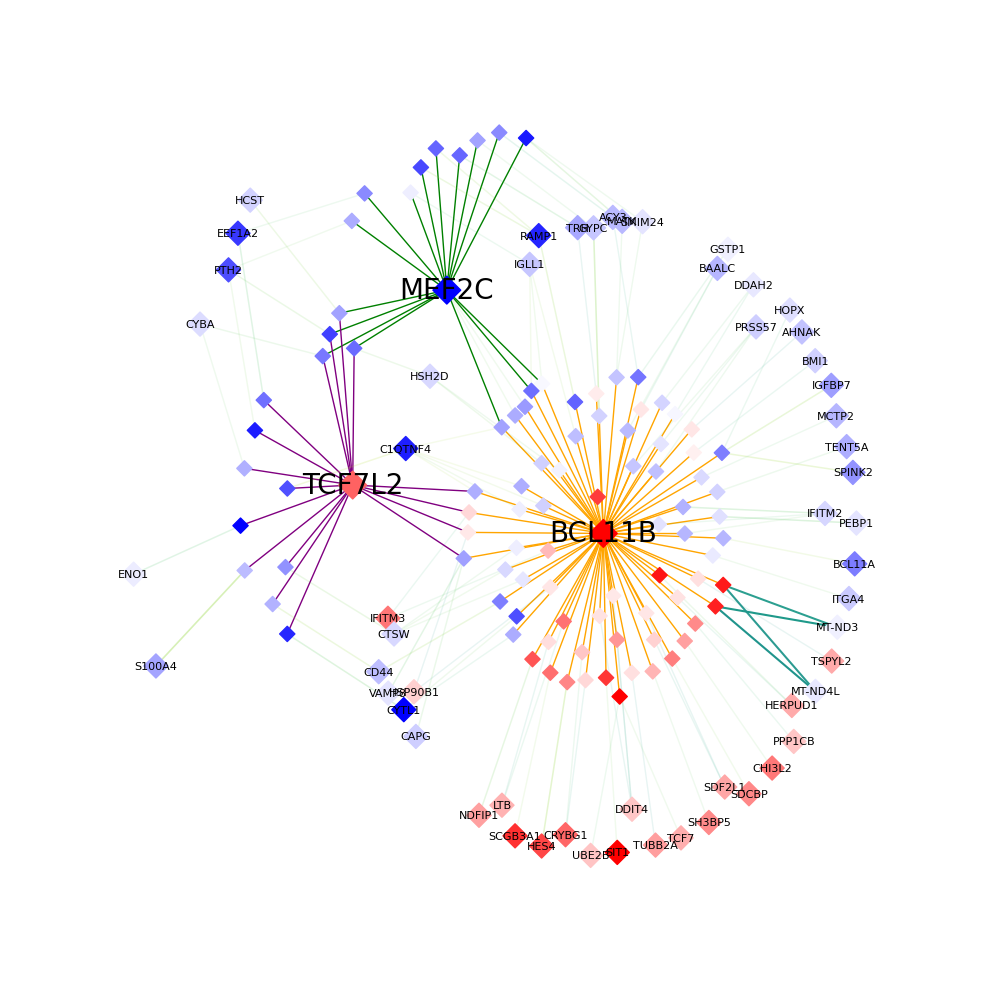

In [23]:
G, pos, edge_tables, node_tables = create_nx_graph(nx_tables,
                   use_edge_tables = ['TF2R','R2G'],
                   color_edge_by = {'TF2R': {'variable' : 'TF', 'category_color' : {'MEF2C': 'Green', 'BCL11B': 'Orange', 'TCF7L2': 'Purple'}},
                                    'R2G': {'variable' : 'rho_R2G', 'continuous_color' : 'viridis', 'v_min': -1, 'v_max': 1}},
                   transparency_edge_by =  {'R2G': {'variable' : 'importance_R2G', 'min_alpha': 0.1, 'v_min': 0}},
                   width_edge_by = {'R2G': {'variable' : 'importance_R2G', 'max_size' :  1.5, 'min_size' : 1}},
                   color_node_by = {'TF': {'variable': 'comparison.bmp.vs.t.specified_Log2FC_T-specified-R', 'continuous_color' : 'bwr'},
                                    'Gene': {'variable': 'comparison.bmp.vs.t.specified_Log2FC_T-specified-R', 'continuous_color' : 'bwr'},
                                    'Region': {'variable': 'comparison.bmp.vs.t.specified_Log2FC_T-specified-R', 'continuous_color' : 'bwr'}},
                   size_node_by = {'TF': {'variable': 'fixed_size', 'fixed_size': 200},
                                    'Gene': {'variable': 'fixed_size', 'fixed_size': 150},
                                    'Region': {'variable': 'fixed_size', 'fixed_size': 60}},
                   shape_node_by = {'TF': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Gene': {'variable': 'fixed_shape', 'fixed_shape': 'ellipse'},
                                    'Region': {'variable': 'fixed_shape', 'fixed_shape': 'diamond'}},
                   label_size_by = {'TF': {'variable': 'fixed_label_size', 'fixed_label_size': 20.0},
                                    'Gene': {'variable': 'fixed_label_size', 'fixed_label_size': 8},
                                    'Region': {'variable': 'fixed_label_size', 'fixed_label_size': 0.0}},
                   layout='kamada_kawai_layout',
                   scale_position_by=400)
plt.figure(figsize=(10,10))
plot_networkx(G, pos)

2024-05-08 16:27:25,973 fontTools.subset INFO     maxp pruned
2024-05-08 16:27:25,982 fontTools.subset INFO     cmap pruned
2024-05-08 16:27:25,983 fontTools.subset INFO     kern dropped
2024-05-08 16:27:25,983 fontTools.subset INFO     post pruned
2024-05-08 16:27:25,985 fontTools.subset INFO     FFTM dropped
2024-05-08 16:27:25,987 fontTools.subset INFO     GPOS pruned
2024-05-08 16:27:25,991 fontTools.subset INFO     GSUB pruned
2024-05-08 16:27:25,997 fontTools.subset INFO     glyf pruned
2024-05-08 16:27:25,998 fontTools.subset INFO     Added gid0 to subset
2024-05-08 16:27:25,999 fontTools.subset INFO     Added first four glyphs to subset
2024-05-08 16:27:26,000 fontTools.subset INFO     Closing glyph list over 'GSUB': 38 glyphs before
2024-05-08 16:27:26,001 fontTools.subset INFO     Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'eight', 'five', 'four', 'hyphen', 'nine', '

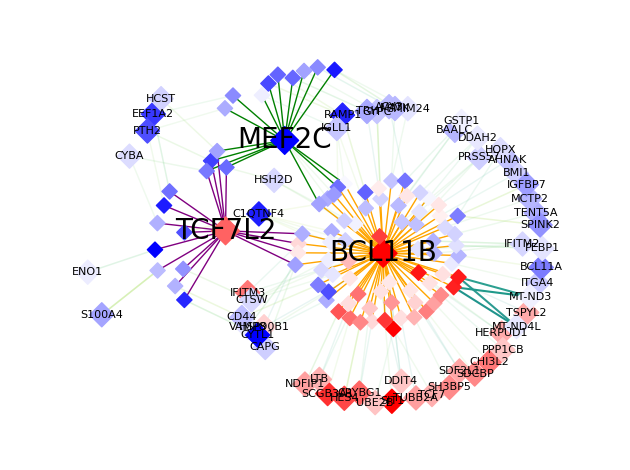

In [29]:
import networkx as nx
nx.draw_networkx_nodes(G, pos, node_color=nx.get_node_attributes(G,'color').values(),
                        node_size=list(nx.get_node_attributes(G,'size').values()),
                        node_shape = 'D')
nx.draw_networkx_edges(G, pos, edge_color = nx.get_edge_attributes(G,'color').values(),
                        width = list(nx.get_edge_attributes(G,'width').values()))
fontsize_d = {y:x['size'] for x,y in zip(list(nx.get_node_attributes(G,'font').values()),list(nx.get_node_attributes(G,'label').values())) if x['size'] != 0.0}
fontcolor_d = {y:x['color'] for x,y in zip(list(nx.get_node_attributes(G,'font').values()),list(nx.get_node_attributes(G,'label').values())) if x['size'] != 0.0}
for node, (x, y) in pos.items():
    if node in fontsize_d.keys():
        plt.text(x, y, node, fontsize=fontsize_d[node], color=fontcolor_d[node],  ha='center', va='center')
ax = plt.gca()
ax.margins(0.11)
plt.tight_layout()
plt.axis("off")
plt.savefig("BMPlike_TSpec_Network.pdf", bbox_inches='tight')
plt.show()